In [36]:
print("hello")

hello


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
df = pd.read_csv("https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv")

In [39]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [40]:
df.shape

(200, 5)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [42]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [43]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


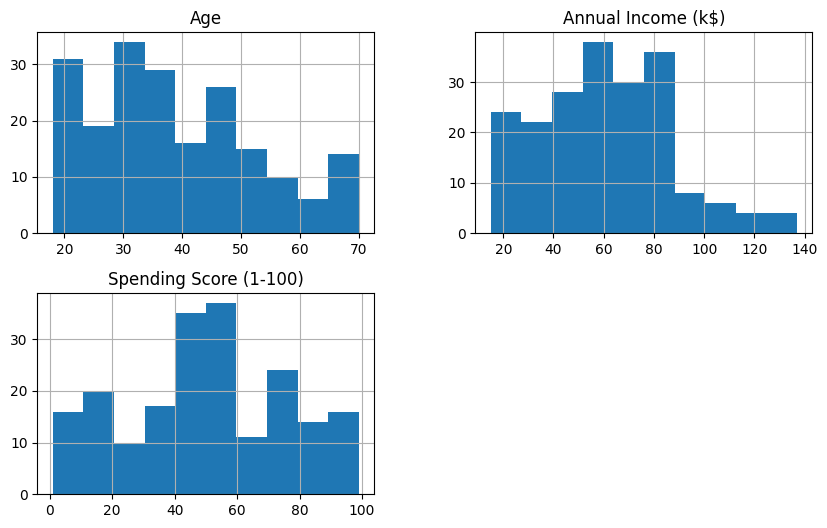

In [44]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].hist(figsize=(10, 6))
plt.show()


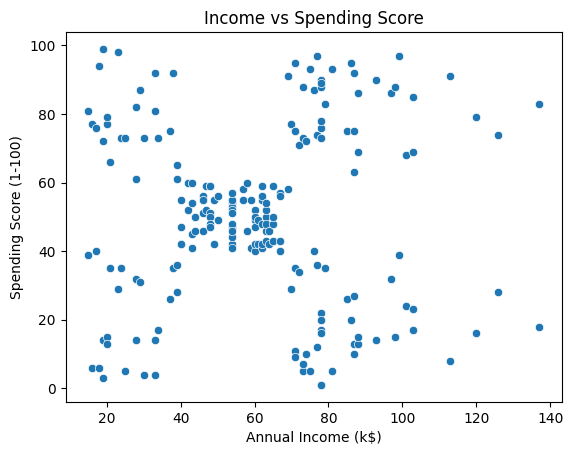

In [45]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Income vs Spending Score')
plt.show()


In [46]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [47]:
from sklearn.preprocessing import StandardScaler


In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [49]:
from sklearn.cluster import KMeans

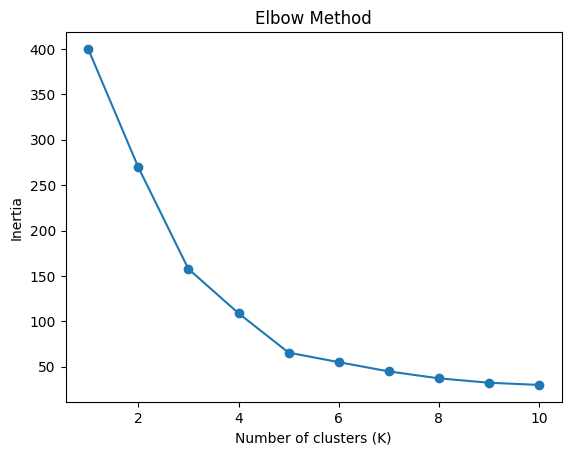

In [50]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [51]:
from sklearn.metrics import silhouette_score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.321
K=3, Silhouette Score=0.467
K=4, Silhouette Score=0.494
K=5, Silhouette Score=0.555
K=6, Silhouette Score=0.540
K=7, Silhouette Score=0.528
K=8, Silhouette Score=0.455
K=9, Silhouette Score=0.457
K=10, Silhouette Score=0.443


In [52]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [53]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


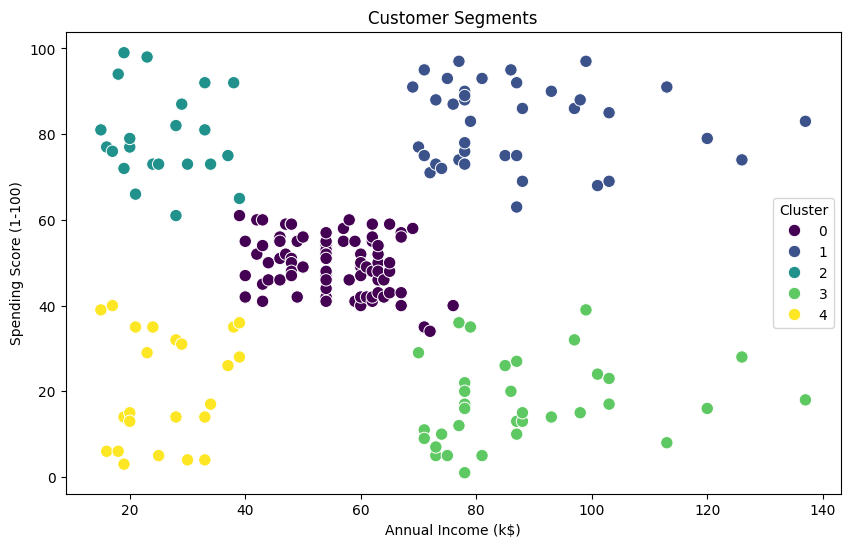

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=80
)
plt.title('Customer Segments')
plt.show()


In [55]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [55]:
# Cluster 0: Mid income (~55k) and mid spending (~50) — balanced on both. These are people who do spend at malls but are very selective about it. I'll call them the "Wise Ones".
# Cluster 1: High income (~87k) and high spending (~82) — these are people who regularly shop at malls and enjoy it. I'll call them the "Enthusiasts".
# Cluster 2: Low income (~26k) but high spending (~79) — likely young people spending a high proportion of a modest income. Let's call them the "Ambitious Youth".
# Cluster 3: High income (~88k) but low spending (~17) — people who can clearly afford to shop but usually don't. The "Busy Bees".
# Cluster 4: Low income (~26k) and low spending (~21) — probably budget-tight shoppers without much to spare. We'll be calling them the "Value Seekers".

In [ ]:
# I'm reading each segment through a simple value-vs-potential lens: how much they spend now, and how much more they realistically could — then matching the marketing effort to that.
# Wise Ones have the budget and the need, they're just cautious and like to weigh their options. The goal is to show them more of what's available — given their age, WhatsApp updates, direct calls and emails would land well.
# Enthusiasts are already in a good position, so they don't need convincing — simple reminders would do the job to prompt sales.
# Ambitious Youth have the appetite to spend but not the deep budget, so promos and offers will help the cause.
# Busy Bees can afford to spend but don't — likely because they don't have the time to come in. This is probably our biggest untapped opportunity, so more home-shopping options should be available to them.
# Value Seekers are tight on budget, so we should focus more on how often they come in than on the size of each basket — general reach with big footfall drivers like End of Season Sale (EOSS) and clearance hoardings.